In [1]:
# import os
# import re
# import pandas as pd
# from pathlib import Path
# import numpy as np
from parse_batch_test_logs import (
    process_all_folders, add_std_columns,
    plot_column_over_iterations,
    extract_final_iteration_data,
    extract_final_iteration_stats_for_model,
    plot_final_iteration_scatter,
    plot_final_iteration_scatter_per_metric,
    extract_final_wide_df
    )

In [2]:
LOGS_DIR = r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\logs\test\batch_test_results\logs"

In [3]:
# Process all folders
dataframes = process_all_folders(LOGS_DIR)

Processing folder: HSTL
  Found 1 log files
Processing folder: kaggle
  Found 20 log files
Processing folder: med-circleloss
  Found 32 log files
Processing folder: p3d
  Found 20 log files
Processing folder: p3d-circleloss
  Found 40 log files


In [4]:
dataframes.pop('HSTL', None)

,iterations,NM,BG,CL,NM_Incl,BG_Incl,CL_Incl,NM_Excl,BG_Excl,CL_Excl
0,80000,"[96.6, 98.9, 98.9, 98.2, 97.0, 96.2, 97.9, 99....","[93.8, 97.7, 97.3, 96.87, 96.1, 93.6, 95.4, 97...","[85.5, 94.1, 94.9, 92.2, 90.8, 85.8, 89.2, 91....",98.1,96.4,90.7,97.9,96.2,89.9


In [5]:
model_names = dataframes.keys()
print(model_names)

dataframes['kaggle'].tail()

dict_keys(['kaggle', 'med-circleloss', 'p3d', 'p3d-circleloss'])


,iterations,NM,BG,CL,NM_Incl,BG_Incl,CL_Incl,NM_Excl,BG_Excl,CL_Excl
15,80000,"[96.2, 98.4, 99.0, 97.8, 97.1, 95.8, 97.6, 98....","[93.0, 96.7, 97.1, 96.06, 95.1, 91.8, 94.1, 97...","[80.9, 92.3, 94.8, 92.2, 88.2, 83.4, 86.0, 91....",97.9,95.7,89.0,97.7,95.4,88.0
16,85000,"[96.5, 98.4, 99.0, 97.8, 96.8, 95.7, 97.5, 99....","[93.9, 96.6, 97.1, 96.26, 94.8, 91.7, 94.2, 97...","[81.1, 92.8, 94.8, 92.4, 88.3, 83.6, 86.4, 92....",97.9,95.9,89.2,97.7,95.6,88.3
17,90000,"[96.4, 98.3, 98.9, 98.0, 97.0, 96.0, 97.5, 99....","[93.9, 96.6, 97.1, 96.26, 95.1, 91.6, 94.1, 97...","[81.0, 93.2, 94.6, 92.6, 88.1, 83.4, 86.0, 91....",97.9,95.9,89.1,97.8,95.6,88.2
18,95000,"[96.4, 98.4, 99.0, 97.8, 96.8, 95.8, 97.3, 99....","[93.9, 96.5, 97.1, 96.16, 94.8, 92.0, 94.1, 97...","[81.1, 92.8, 94.8, 92.1, 88.1, 84.0, 86.4, 92....",97.9,95.9,89.2,97.7,95.5,88.3
19,100000,"[96.4, 98.3, 98.9, 98.0, 97.0, 96.1, 97.5, 99....","[94.0, 96.6, 97.1, 96.26, 95.1, 91.4, 93.9, 97...","[81.1, 93.1, 94.9, 92.6, 88.0, 84.5, 86.4, 91....",97.9,95.9,89.3,97.8,95.5,88.4


In [6]:
df_kaggle = add_std_columns(dataframes['kaggle'])
df_kaggle.tail()

,iterations,NM,BG,CL,NM_Incl,BG_Incl,CL_Incl,NM_Excl,BG_Excl,CL_Excl,NM_std,BG_std,CL_std
15,80000,"[96.2, 98.4, 99.0, 97.8, 97.1, 95.8, 97.6, 98....","[93.0, 96.7, 97.1, 96.06, 95.1, 91.8, 94.1, 97...","[80.9, 92.3, 94.8, 92.2, 88.2, 83.4, 86.0, 91....",97.9,95.7,89.0,97.7,95.4,88.0,1.3,2.2,5.7
16,85000,"[96.5, 98.4, 99.0, 97.8, 96.8, 95.7, 97.5, 99....","[93.9, 96.6, 97.1, 96.26, 94.8, 91.7, 94.2, 97...","[81.1, 92.8, 94.8, 92.4, 88.3, 83.6, 86.4, 92....",97.9,95.9,89.2,97.7,95.6,88.3,1.3,2.1,5.5
17,90000,"[96.4, 98.3, 98.9, 98.0, 97.0, 96.0, 97.5, 99....","[93.9, 96.6, 97.1, 96.26, 95.1, 91.6, 94.1, 97...","[81.0, 93.2, 94.6, 92.6, 88.1, 83.4, 86.0, 91....",97.9,95.9,89.1,97.8,95.6,88.2,1.3,2.1,5.6
18,95000,"[96.4, 98.4, 99.0, 97.8, 96.8, 95.8, 97.3, 99....","[93.9, 96.5, 97.1, 96.16, 94.8, 92.0, 94.1, 97...","[81.1, 92.8, 94.8, 92.1, 88.1, 84.0, 86.4, 92....",97.9,95.9,89.2,97.7,95.5,88.3,1.3,2.0,5.4
19,100000,"[96.4, 98.3, 98.9, 98.0, 97.0, 96.1, 97.5, 99....","[94.0, 96.6, 97.1, 96.26, 95.1, 91.4, 93.9, 97...","[81.1, 93.1, 94.9, 92.6, 88.0, 84.5, 86.4, 91....",97.9,95.9,89.3,97.8,95.5,88.4,1.3,2.1,5.5


In [7]:
df_kaggle.iloc[0:-1].drop(columns=['NM','BG','CL','NM_Incl','BG_Incl','CL_Incl'])

,iterations,NM_Excl,BG_Excl,CL_Excl,NM_std,BG_std,CL_std
0,5000,95.8,92.6,82.4,2.6,3.7,6.1
1,10000,97.1,94.2,85.3,1.7,2.8,6.0
2,15000,97.2,94.4,86.1,1.9,3.0,6.3
3,20000,97.4,94.7,85.9,1.9,2.8,6.6
4,25000,97.2,94.4,86.3,1.8,3.1,6.2
5,30000,97.5,95.1,87.1,1.5,2.4,5.5
6,35000,97.4,95.0,86.6,1.8,2.4,6.2
7,40000,97.3,95.2,86.8,1.8,2.5,6.3
8,45000,97.2,94.8,86.5,1.8,2.8,6.5
9,50000,97.7,95.5,87.6,1.4,2.1,5.4


In [8]:
full_info_dfs = {name: add_std_columns(df) for name, df in dataframes.items()}

[5000, 5000, 5000, 2500]
[5000, 5000, 5000, 2500]
5000
Plot saved to: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\NM_Excl.jpg


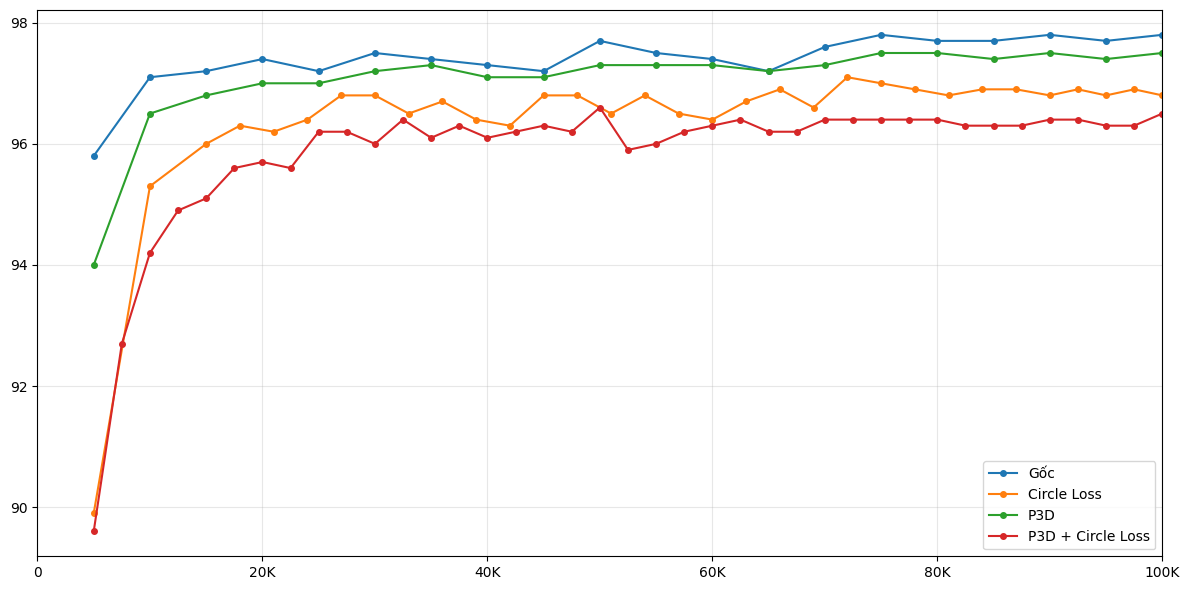

[5000, 5000, 5000, 2500]
[5000, 5000, 5000, 2500]
5000
Plot saved to: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\BG_Excl.jpg


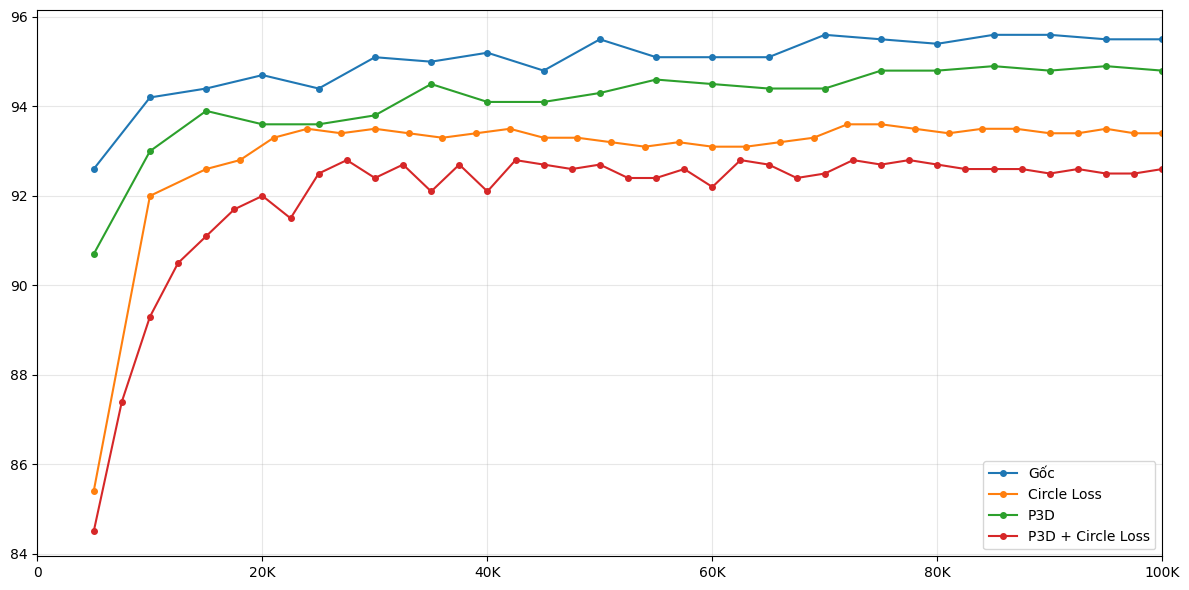

[5000, 5000, 5000, 2500]
[5000, 5000, 5000, 2500]
5000
Plot saved to: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\CL_Excl.jpg


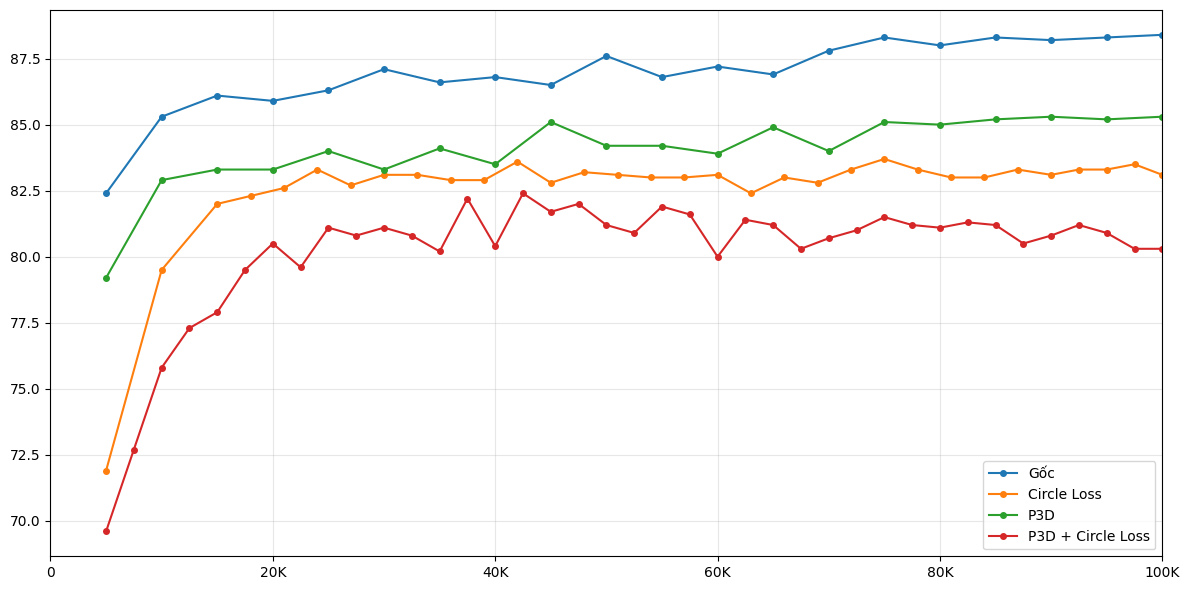

[5000, 5000, 5000, 2500]
[5000, 5000, 5000, 2500]
5000
Plot saved to: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\NM_Incl.jpg


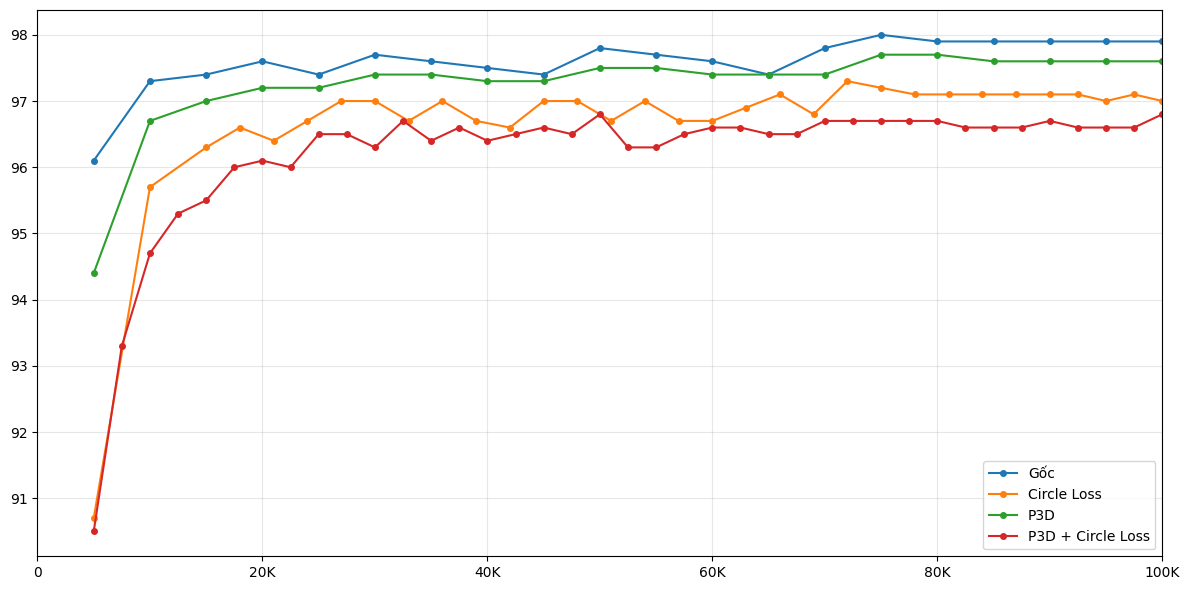

[5000, 5000, 5000, 2500]
[5000, 5000, 5000, 2500]
5000
Plot saved to: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\BG_Incl.jpg


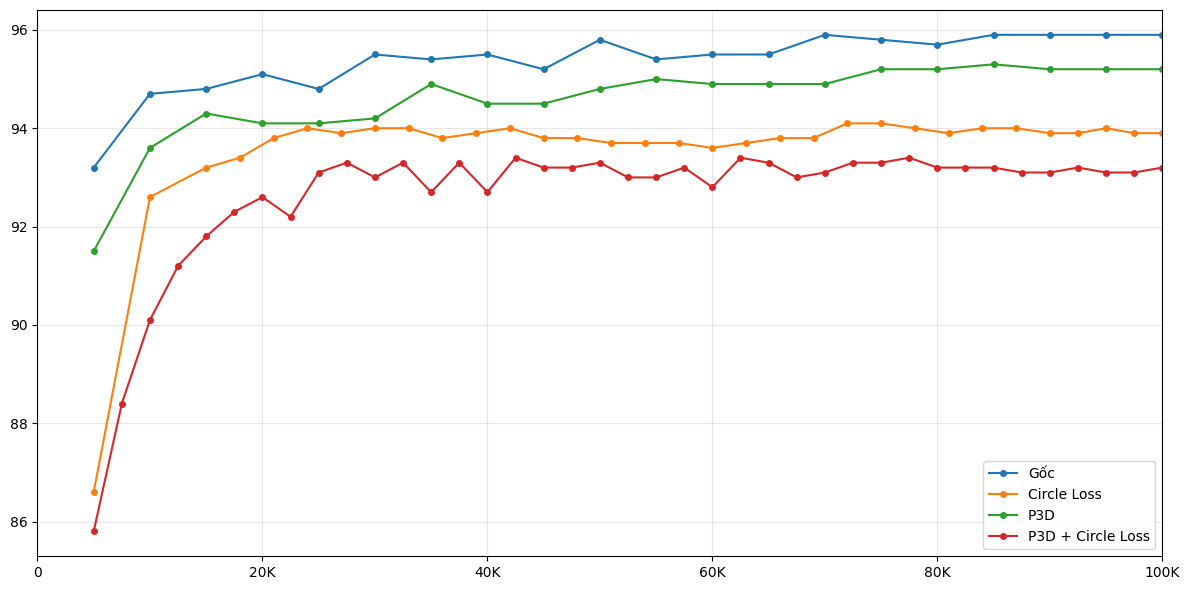

[5000, 5000, 5000, 2500]
[5000, 5000, 5000, 2500]
5000
Plot saved to: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\CL_Incl.jpg


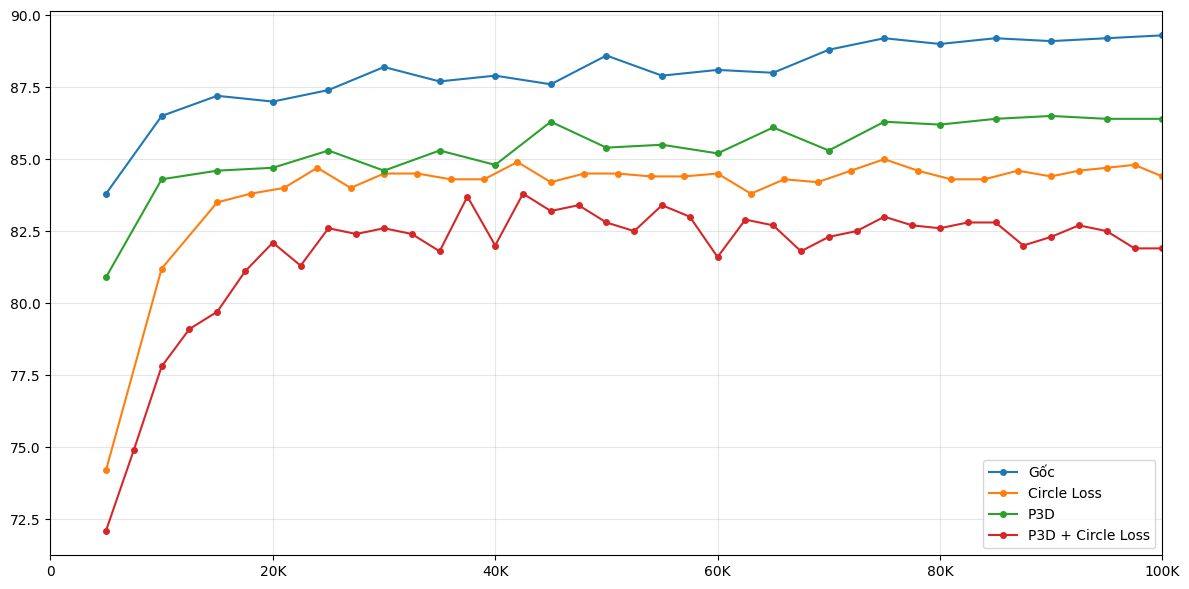

In [9]:
plot_column_over_iterations(dataframes_dict=dataframes, column_name='NM_Excl', save_path=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)
plot_column_over_iterations(dataframes_dict=dataframes, column_name='BG_Excl', save_path=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)
plot_column_over_iterations(dataframes_dict=dataframes, column_name='CL_Excl', save_path=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)
plot_column_over_iterations(dataframes_dict=dataframes, column_name='NM_Incl', save_path=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)
plot_column_over_iterations(dataframes_dict=dataframes, column_name='BG_Incl', save_path=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)
plot_column_over_iterations(dataframes_dict=dataframes, column_name='CL_Incl', save_path=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)

In [10]:
# dataframes with std
dfs = {name:add_std_columns(df) for name, df in dataframes.items()}

[5000, 5000, 5000, 2500]
[5000, 5000, 5000, 2500]
5000
Plot saved to: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\NM_std.jpg


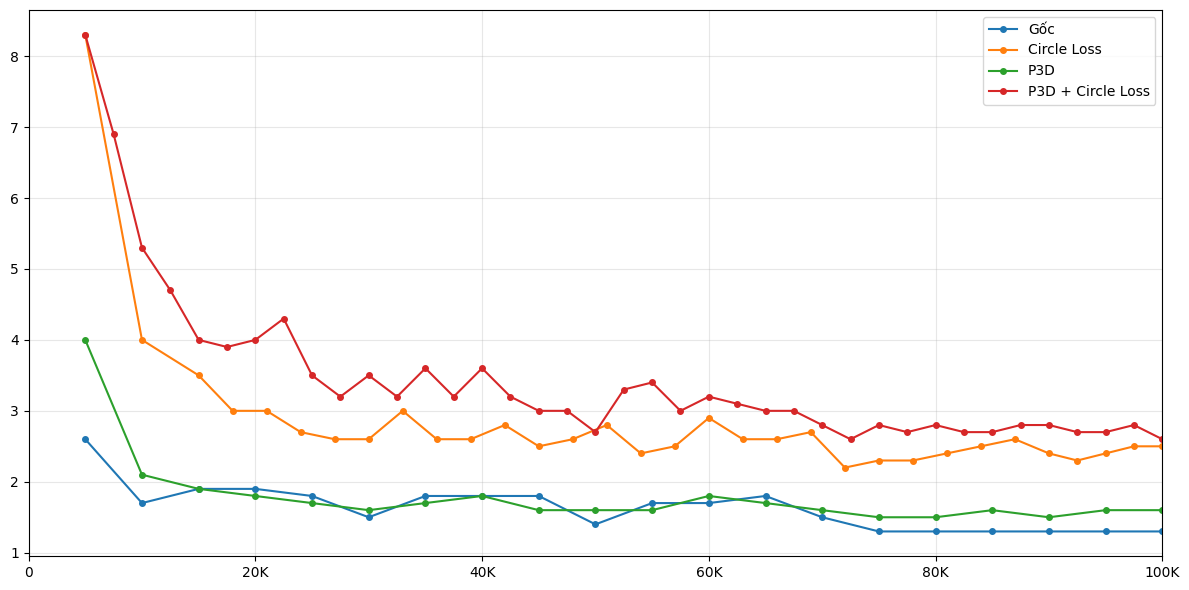

[5000, 5000, 5000, 2500]
[5000, 5000, 5000, 2500]
5000
Plot saved to: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\BG_std.jpg


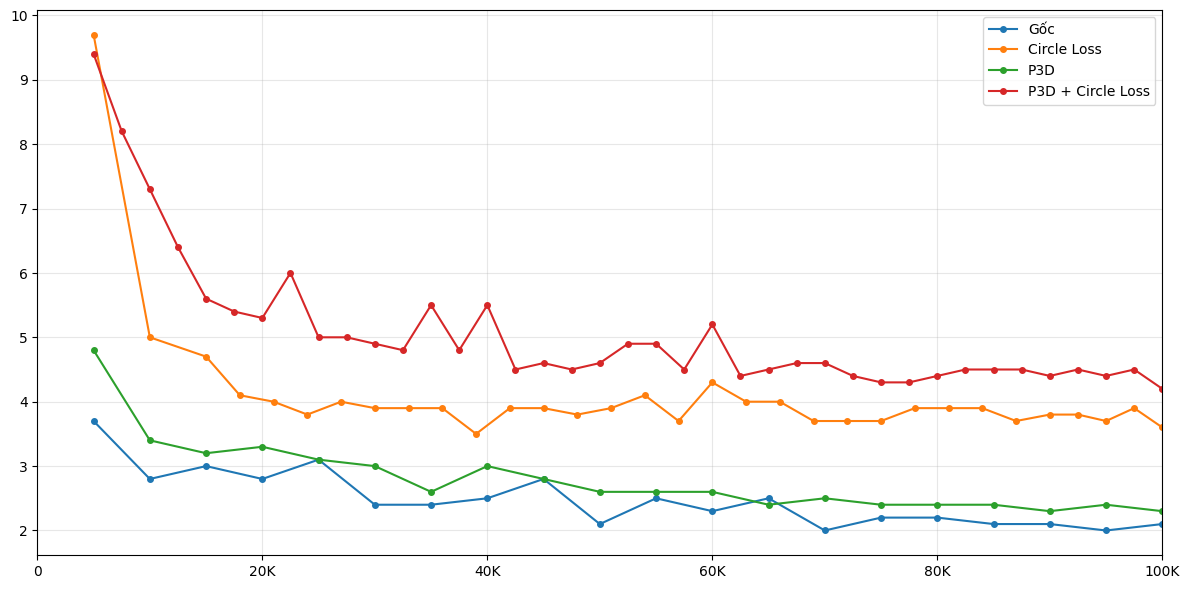

[5000, 5000, 5000, 2500]
[5000, 5000, 5000, 2500]
5000
Plot saved to: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\CL_std.jpg


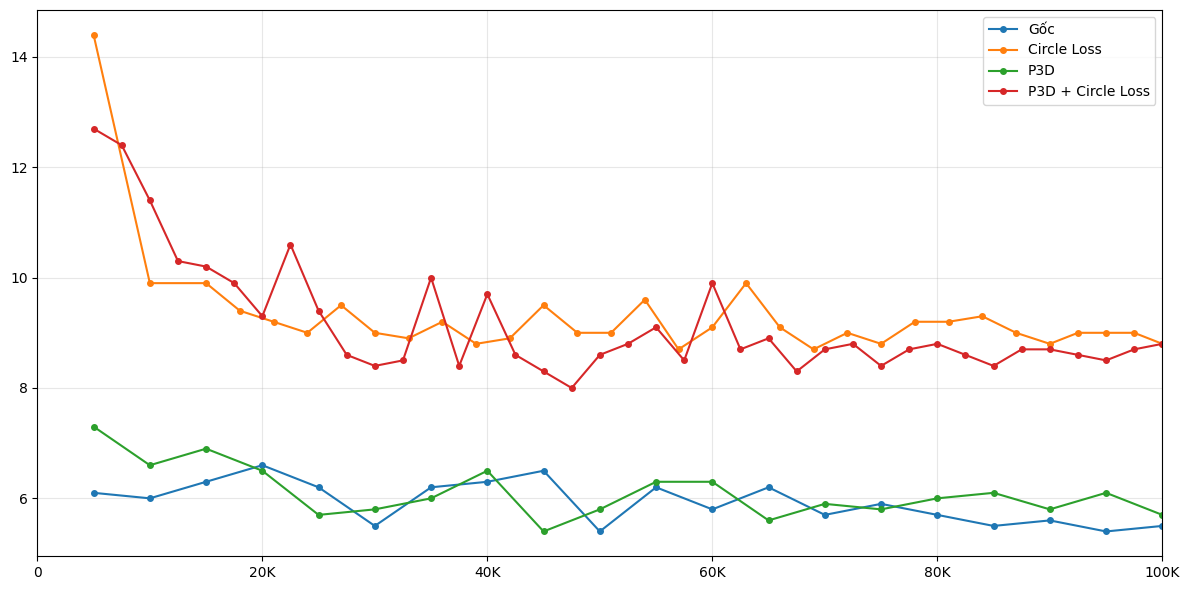

In [11]:
plot_column_over_iterations(dataframes_dict=dfs, column_name='NM_std', save_path=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)
plot_column_over_iterations(dataframes_dict=dfs, column_name='BG_std', save_path=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)
plot_column_over_iterations(dataframes_dict=dfs, column_name='CL_std', save_path=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)

In [12]:
dataframes['kaggle']

,iterations,NM,BG,CL,NM_Incl,BG_Incl,CL_Incl,NM_Excl,BG_Excl,CL_Excl
0,5000,"[92.9, 96.2, 98.3, 97.0, 95.4, 93.7, 95.6, 98....","[89.5, 94.3, 95.8, 93.94, 91.4, 86.8, 90.9, 95...","[74.2, 87.1, 88.7, 87.7, 82.6, 77.6, 82.3, 86....",96.1,93.2,83.8,95.8,92.6,82.4
1,10000,"[95.3, 97.4, 98.8, 97.3, 96.2, 95.5, 97.2, 99....","[91.6, 95.6, 96.8, 95.05, 93.4, 89.5, 92.9, 96...","[77.5, 90.8, 93.0, 90.2, 84.8, 79.9, 84.5, 89....",97.3,94.7,86.5,97.1,94.2,85.3
2,15000,"[96.3, 98.2, 99.2, 97.6, 95.4, 93.9, 97.1, 99....","[91.1, 95.7, 96.8, 94.85, 93.8, 89.1, 93.3, 97...","[77.3, 89.9, 93.9, 91.5, 86.4, 80.8, 84.8, 90....",97.4,94.8,87.2,97.2,94.4,86.1
3,20000,"[96.0, 98.6, 99.1, 97.7, 96.1, 95.4, 97.8, 99....","[92.6, 96.2, 97.2, 95.35, 94.1, 90.7, 93.3, 97...","[76.4, 91.1, 93.8, 91.6, 86.6, 81.8, 85.1, 90....",97.6,95.1,87.0,97.4,94.7,85.9
4,25000,"[95.1, 98.3, 99.0, 97.5, 96.0, 94.8, 96.5, 99....","[91.4, 96.4, 97.3, 94.75, 93.6, 89.5, 92.4, 96...","[78.7, 91.4, 93.4, 91.1, 85.8, 80.6, 85.6, 89....",97.4,94.8,87.4,97.2,94.4,86.3
5,30000,"[95.7, 98.5, 99.1, 97.7, 96.0, 95.6, 97.8, 99....","[93.4, 96.2, 97.2, 94.85, 94.0, 90.5, 94.2, 97...","[80.4, 91.9, 94.0, 91.8, 86.5, 82.4, 85.8, 90....",97.7,95.5,88.2,97.5,95.1,87.1
6,35000,"[95.3, 98.6, 99.1, 98.1, 96.2, 94.7, 97.1, 99....","[92.4, 95.9, 97.0, 95.56, 94.2, 90.6, 93.6, 97...","[78.4, 90.7, 93.3, 91.6, 85.7, 81.5, 85.5, 91....",97.6,95.4,87.7,97.4,95.0,86.6
7,40000,"[95.2, 98.1, 98.9, 97.8, 96.8, 95.6, 97.7, 99....","[92.6, 96.7, 97.1, 96.16, 94.4, 91.5, 94.3, 97...","[79.8, 92.0, 94.5, 92.2, 87.0, 83.2, 85.8, 90....",97.5,95.5,87.9,97.3,95.2,86.8
8,45000,"[95.0, 98.0, 99.1, 97.5, 96.3, 94.8, 96.7, 99....","[92.9, 96.6, 97.1, 95.35, 94.0, 90.3, 92.5, 96...","[78.2, 92.1, 93.7, 90.8, 87.2, 81.5, 85.5, 89....",97.4,95.2,87.6,97.2,94.8,86.5
9,50000,"[96.5, 98.7, 99.1, 97.8, 96.6, 95.7, 97.6, 99....","[94.1, 96.8, 97.4, 95.35, 94.4, 91.4, 94.2, 97...","[81.0, 92.8, 94.0, 91.3, 86.1, 80.9, 86.8, 91....",97.8,95.8,88.6,97.7,95.5,87.6


In [13]:
final_df = extract_final_iteration_data(dataframes_dict=dataframes)

In [14]:
final_df

,model_name,iteration,view,NM,BG,CL
0,kaggle,100000,0,96.4,94.00,81.1
1,kaggle,100000,18,98.3,96.60,93.1
2,kaggle,100000,36,98.9,97.10,94.9
3,kaggle,100000,54,98.0,96.26,92.6
4,kaggle,100000,72,97.0,95.10,88.0
5,kaggle,100000,90,96.1,91.40,84.5
6,kaggle,100000,108,97.5,93.90,86.4
7,kaggle,100000,126,99.2,97.50,91.7
8,kaggle,100000,144,99.4,98.40,92.9
9,kaggle,100000,162,99.2,97.78,90.7


In [15]:
# export this 100K summary in 4 dfs for each model
kaggle_df = final_df[final_df['model_name'] == 'kaggle'].drop(columns=['iteration', 'model_name'])
kaggle_df

,view,NM,BG,CL
0,0,96.4,94.00,81.1
1,18,98.3,96.60,93.1
2,36,98.9,97.10,94.9
3,54,98.0,96.26,92.6
4,72,97.0,95.10,88.0
5,90,96.1,91.40,84.5
6,108,97.5,93.90,86.4
7,126,99.2,97.50,91.7
8,144,99.4,98.40,92.9
9,162,99.2,97.78,90.7


Saved: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\final_iteration_scatter_NM.png


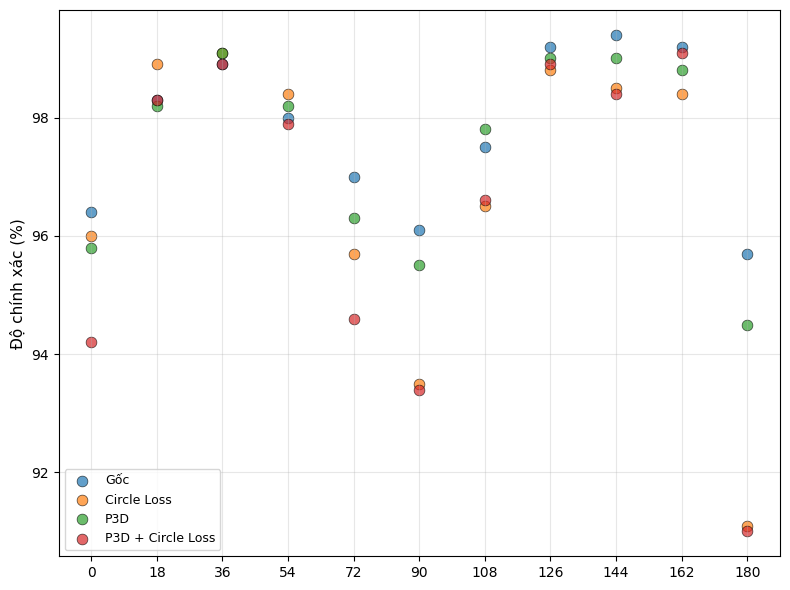

Saved: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\final_iteration_scatter_BG.png


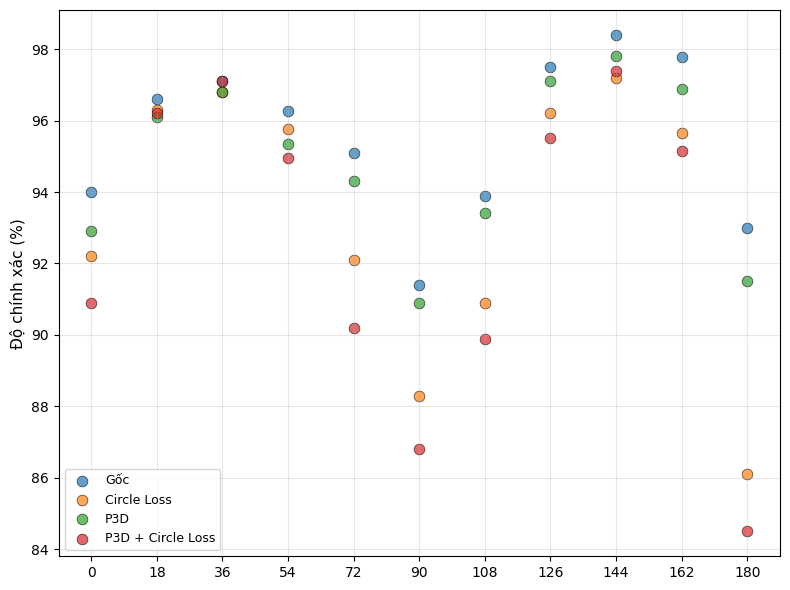

Saved: C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils\final_iteration_scatter_CL.png


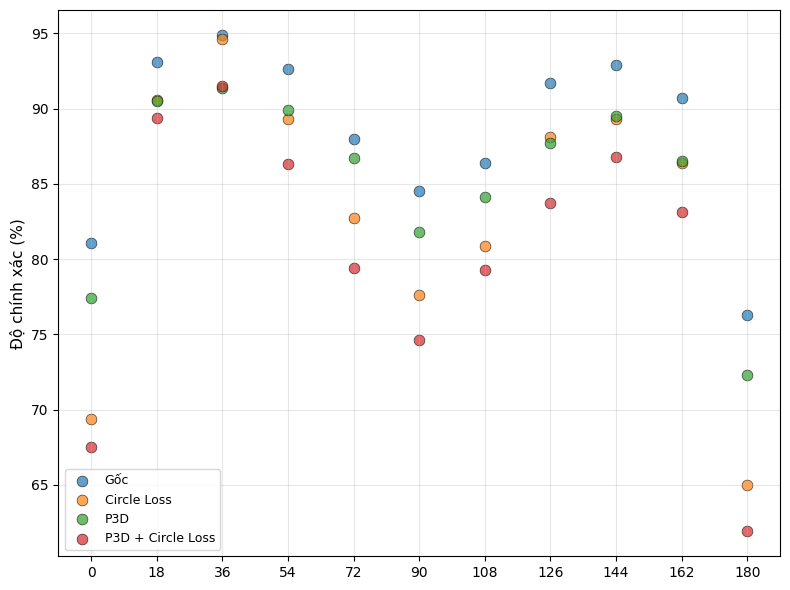

In [16]:
plot_final_iteration_scatter_per_metric(final_df=final_df, save_dir=r"C:\Users\Admin\Documents\CV\biometrics\src\HSTL\utils",use_vn_labels=True)

In [17]:
nm_wide = extract_final_wide_df(dfs, "NM")
bg_wide = extract_final_wide_df(dfs, "BG")
cl_wide = extract_final_wide_df(dfs, "CL")

In [18]:
nm_wide

,model_name,0,18,36,54,72,90,108,126,144,162,180,excluded_mean,excluded_std
0,kaggle,96.4,98.3,98.9,98.0,97.0,96.1,97.5,99.2,99.4,99.2,95.7,97.8,1.3
1,med-circleloss,96.0,98.9,99.1,98.4,95.7,93.5,96.5,98.8,98.5,98.4,91.1,96.8,2.5
2,p3d,95.8,98.2,99.1,98.2,96.3,95.5,97.8,99.0,99.0,98.8,94.5,97.5,1.6
3,p3d-circleloss,94.2,98.3,98.9,97.9,94.6,93.4,96.6,98.9,98.4,99.1,91.0,96.5,2.6


In [19]:
kaggle_100k_df = extract_final_iteration_stats_for_model(dataframes_dict=full_info_dfs, model_name='kaggle')
# export to latex or string only
# print(kaggle_100k_df.to_latex(index=False))
print(kaggle_100k_df.to_string())

  metric  view_0  view_18  view_36  view_54  view_72  view_90  view_108  view_126  view_144  view_162  view_180  Incl  Excl  Std
0     NM    96.4     98.3     98.9    98.00     97.0     96.1      97.5      99.2      99.4     99.20      95.7  97.9  97.8  1.3
1     BG    94.0     96.6     97.1    96.26     95.1     91.4      93.9      97.5      98.4     97.78      93.0  95.9  95.5  2.1
2     CL    81.1     93.1     94.9    92.60     88.0     84.5      86.4      91.7      92.9     90.70      76.3  89.3  88.4  5.5


In [20]:
p3d_100k_df = extract_final_iteration_stats_for_model(dataframes_dict=full_info_dfs, model_name='p3d')
print(p3d_100k_df.to_string())

  metric  view_0  view_18  view_36  view_54  view_72  view_90  view_108  view_126  view_144  view_162  view_180  Incl  Excl  Std
0     NM    95.8     98.2     99.1    98.20     96.3     95.5      97.8      99.0      99.0     98.80      94.5  97.6  97.5  1.6
1     BG    92.9     96.1     96.8    95.35     94.3     90.9      93.4      97.1      97.8     96.87      91.5  95.2  94.8  2.3
2     CL    77.4     90.5     91.4    89.90     86.7     81.8      84.1      87.7      89.5     86.50      72.3  86.4  85.3  5.7


In [21]:
circle_100k_df = extract_final_iteration_stats_for_model(dataframes_dict=full_info_dfs, model_name='med-circleloss')
print(circle_100k_df.to_string())

  metric  view_0  view_18  view_36  view_54  view_72  view_90  view_108  view_126  view_144  view_162  view_180  Incl  Excl  Std
0     NM    96.0     98.9     99.1    98.40     95.7     93.5      96.5      98.8      98.5     98.40      91.1  97.0  96.8  2.5
1     BG    92.2     96.3     96.8    95.76     92.1     88.3      90.9      96.2      97.2     95.66      86.1  93.9  93.4  3.6
2     CL    69.4     90.6     94.6    89.30     82.7     77.6      80.9      88.1      89.3     86.40      65.0  84.4  83.1  8.8


In [22]:
p3d_circle_100k_df = extract_final_iteration_stats_for_model(dataframes_dict=full_info_dfs, model_name='p3d-circleloss')
print(p3d_circle_100k_df.to_string())

  metric  view_0  view_18  view_36  view_54  view_72  view_90  view_108  view_126  view_144  view_162  view_180  Incl  Excl  Std
0     NM    94.2     98.3     98.9    97.90     94.6     93.4      96.6      98.9      98.4     99.10      91.0  96.8  96.5  2.6
1     BG    90.9     96.2     97.1    94.95     90.2     86.8      89.9      95.5      97.4     95.15      84.5  93.2  92.6  4.2
2     CL    67.5     89.4     91.5    86.30     79.4     74.6      79.3      83.7      86.8     83.10      61.9  81.9  80.3  8.8
